## Imports


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sector mapping (SBI → naam)
sector_namen = {
    'A': 'Landbouw, bosbouw en visserij',
    'B': 'Delfstoffen',
    'C': 'Industrie',
    'D': 'Energie',
    'E': 'Water & afval',
    'F': 'Bouwnijverheid',
    'G': 'Groot- en detailhandel; reparatie van auto’s',
    'H': 'Vervoer en opslag',
    'I': 'Horeca',
    'J': 'Informatie & communicatie',
    'K': 'Financieel instellingen',
    'L': 'Vastgoed',
    'M': 'Zakelijke dienstverlening',
    'N': 'Overige zakelijke diensten',
    'O': 'Overheid',
    'P': 'Onderwijs',
    'Q': 'Zorg',
    'R': 'Cultuur & recreatie',
    'S': 'Overige dienstverlening'
}



# 1. Business Understanding - Sectorale Dynamiek
In dit onderdeel van het onderzoek focussen we op de historische ontwikkeling van de werkgelegenheid binnen de provincie Flevoland.

## Doelstelling
Het identificeren van structurele trends (groei, stabiliteit of krimp) per sector over de afgelopen jaren. Deze inzichten vormen de basis voor de uiteindelijke 10-jaars prognose.

## Onderzoeksvraag (Deelvraag 2)
> Welke sectoren laten structurele groei, stabiliteit of krimp zien in de historische werkgelegenheidsdata van Flevoland?

## Definities & Afbakening
* **Target Variabele:** `wp` (Werkzame Personen).
* **Segmentatie:** Op basis van `sbi_code` (Standaard Bedrijfsindeling).
* **Regio:** Provincie Flevoland (gefilterd op `gemeente_code`).
* **Dynamiek:** De relatieve (procentuele) verandering van de werkgelegenheid per jaar.

## Verwacht Resultaat
Een gecategoriseerde lijst van sectoren en visuele trendlijnen die de economische verschuivingen in de provincie blootleggen.

<br></br>

# Eerste verkenning +  Data inladen

In [4]:
# Data inladen
df = pd.read_excel('../../Data/raw/dataset.xlsx')
print(df.columns.tolist())

print(df.shape)
print(df.columns)
df.head()

['vestnr', 'postcode', 'plaats', 'gemeente_code', 'datum_start', 'datum_einde', 'jaar', 'man_fte', 'vrouw_fte', 'man_pte', 'vrouw_pte', 'wp', 'sector_code', 'sbi_code', 'rechtsvorm', 'rechtsvorm_code', 'bagoppervlak']
(137714, 17)
Index(['vestnr', 'postcode', 'plaats', 'gemeente_code', 'datum_start',
       'datum_einde', 'jaar', 'man_fte', 'vrouw_fte', 'man_pte', 'vrouw_pte',
       'wp', 'sector_code', 'sbi_code', 'rechtsvorm', 'rechtsvorm_code',
       'bagoppervlak'],
      dtype='object')


,vestnr,postcode,plaats,gemeente_code,datum_start,datum_einde,jaar,man_fte,vrouw_fte,man_pte,vrouw_pte,wp,sector_code,sbi_code,rechtsvorm,rechtsvorm_code,bagoppervlak
0,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2015,2,2,0,0,4,A,1241,Besloten Vennootschap (BV),41.0,166.0
1,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2016,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
2,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2017,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
3,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2018,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
4,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2019,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0


De dataset is succesvol ingeladen met behulp van Pandas. De dataset bevat 137.714 rijen en 17 kolommen, wat aangeeft dat het om een omvangrijke dataset gaat met voldoende data voor analyse.

Uit de kolomnamen blijkt dat de dataset informatie bevat over:

Vestigingen (zoals vestnr, postcode, plaats)
Locatie (gemeente_code)
Tijd (jaar, datum_start, datum_einde)
Werkgelegenheid (wp, man_fte, vrouw_fte, man_pte, vrouw_pte)
Sectorindeling (sector_code, sbi_code)
Bedrijfskenmerken (rechtsvorm, bagoppervlak)

De eerste rijen van de dataset laten zien dat:

Elke rij een vestiging per jaar vertegenwoordigt
Eenzelfde vestiging (vestnr) meerdere jaren kan voorkomen (tijdreeksstructuur)
De variabele wp het aantal werkzame personen per vestiging weergeeft
De dataset geschikt lijkt voor tijdreeksanalyse per sector en regio

Deze eerste verkenning bevestigt dat de dataset de benodigde variabelen bevat om de ontwikkeling van werkgelegenheid per sector in Flevoland te analyseren.

In [5]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137714 entries, 0 to 137713
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   vestnr           137714 non-null  int64         
 1   postcode         137714 non-null  object        
 2   plaats           137714 non-null  object        
 3   gemeente_code    137714 non-null  int64         
 4   datum_start      137714 non-null  object        
 5   datum_einde      29225 non-null   datetime64[ns]
 6   jaar             137714 non-null  int64         
 7   man_fte          137714 non-null  int64         
 8   vrouw_fte        137714 non-null  int64         
 9   man_pte          137714 non-null  int64         
 10  vrouw_pte        137714 non-null  int64         
 11  wp               137714 non-null  int64         
 12  sector_code      137714 non-null  object        
 13  sbi_code         137714 non-null  int64         
 14  rechtsvorm       137

vestnr                  0
postcode                0
plaats                  0
gemeente_code           0
datum_start             0
datum_einde        108489
jaar                    0
man_fte                 0
vrouw_fte               0
man_pte                 0
vrouw_pte               0
wp                      0
sector_code             0
sbi_code                0
rechtsvorm             10
rechtsvorm_code        10
bagoppervlak           85
dtype: int64

De dataset bevat 137.714 rijen en 17 kolommen, waarbij de meeste variabelen volledig gevuld zijn. De belangrijkste variabelen voor de analyse, zoals jaar, wp, sbi_code en gemeente_code, bevatten geen missende waarden, wat positief is voor de betrouwbaarheid van de analyse.

De datatypes zijn grotendeels correct:

Numerieke variabelen zoals wp en jaar zijn van het type int, wat geschikt is voor berekeningen.
Categorische variabelen zoals sector_code en plaats zijn van het type object.
datum_einde is van het type datetime, wat geschikt is voor tijdsanalyses.

Er zijn wel enkele missende waarden geconstateerd:

datum_einde bevat veel missende waarden (108.489), wat logisch is omdat veel vestigingen nog actief zijn.
rechtsvorm en rechtsvorm_code missen slechts 10 waarden.
bagoppervlak mist 85 waarden.

Deze missende waarden hebben naar verwachting geen directe invloed op de analyse van werkgelegenheid per sector, aangezien de kernvariabelen volledig zijn ingevuld.

In [6]:
gemeentes_flevoland = [34, 303, 995, 171, 184, 50]
df_flevo = df[df['gemeente_code'].isin(gemeentes_flevoland)].copy()
df_flevo['Sector'] = df_flevo['sector_code'].map(sector_namen)
print(df_flevo.shape)
sorted(df_flevo['jaar'].unique())
df_flevo['jaar'].value_counts().sort_index()

(137714, 18)


jaar
2014    11907
2015    11568
2016    11484
2017    11445
2018    11671
2019    12701
2020    12935
2021    13240
2022    13596
2023    13515
2024    13652
Name: count, dtype: int64

De dataset is gefilterd op gemeenten binnen de provincie Flevoland op basis van de gemeente_code. Hoewel de dataset al gericht lijkt op Flevoland, is deze stap uitgevoerd ter verificatie en om de analyse expliciet te beperken tot de relevante regio.

Na filtering bevat de dataset nog steeds een groot aantal observaties, wat bevestigt dat de dataset volledig betrekking heeft op Flevoland.

Vervolgens is de tijdsdimensie geanalyseerd. De dataset bevat gegevens voor de jaren 2014 tot en met 2024, wat resulteert in een tijdsreeks van 11 jaar.

De verdeling van het aantal vestigingen per jaar is relatief stabiel, met een lichte toename in de latere jaren. Dit wijst op een consistente dataverzameling en maakt de dataset geschikt voor trendanalyse en voorspellingen.

In [7]:
df_flevo.groupby("jaar")["wp"].sum()

jaar
2014    146751
2015    146048
2016    147845
2017    149599
2018    154681
2019    160100
2020    159877
2021    162143
2022    166262
2023    169212
2024    172597
Name: wp, dtype: int64

Om inzicht te krijgen in de ontwikkeling van de werkgelegenheid is het totaal van de variabele wp per jaar berekend.

De resultaten laten een duidelijke stijgende trend zien over de periode 2014–2024. De totale werkgelegenheid neemt toe van ongeveer 146.000 in 2014 naar ruim 172.000 in 2024.

Deze ontwikkeling wijst op een groeiende economie in Flevoland. Daarnaast is de trend relatief stabiel, zonder grote schommelingen, wat duidt op een consistente en betrouwbare dataset.

Deze eerste analyse bevestigt dat de dataset geschikt is voor verdere trendanalyse en modellering.

In [8]:
df_flevo['wp'].value_counts().sort_index()

wp
2       53328
3       18848
4       11992
5        7743
6        5594
        ...  
2353        1
2526        1
2527        1
2687        1
2785        1
Name: count, Length: 579, dtype: int64

Om de variabele wp beter te begrijpen, is de verdeling van de waarden geanalyseerd met behulp van value_counts().

Uit de resultaten blijkt dat:

De meeste vestigingen een relatief laag aantal werkzame personen hebben (bijvoorbeeld waarden zoals 2, 3, 4, 5).
Er daarnaast een groot aantal unieke en hogere waarden voorkomt (tot boven de 2000).
In totaal zijn er 579 verschillende waarden voor wp.

Dit wijst erop dat de variabele wp geen vaste klassenindeling bevat, maar een brede spreiding van waarden heeft. Hierdoor lijkt wp een directe (of sterk gedetailleerde) weergave te zijn van het aantal werkzame personen per vestiging.

Hoewel wp grotendeels lijkt te bestaan uit concrete aantallen werkzame personen, komen er ook zeer hoge en unieke waarden voor. Dit kan wijzen op uitschieters of specifieke grote vestigingen.

In [9]:
df_flevo['sbi_code'].nunique()
df_flevo['sbi_code'].value_counts().head(10)


sbi_code
111      3541
8891     2874
56102    2680
70221    2573
56101    2452
1134     2404
45112    2313
85201    2137
6201     2042
4120     2014
Name: count, dtype: int64

Om inzicht te krijgen in de sectorale verdeling van de dataset is het aantal unieke sbi_code waarden bepaald en zijn de meest voorkomende codes geanalyseerd.

Uit de analyse blijkt dat:

De dataset 794 unieke SBI-codes bevat, wat wijst op een hoge mate van detail binnen de sectorindeling.
De meest voorkomende SBI-codes betreffen sectoren zoals:
111 (landbouwactiviteiten)
56102 en 56101 (horeca)
70221 (advies/consultancy)
6201 (IT-dienstverlening)

Dit laat zien dat de dataset een brede spreiding van economische activiteiten in Flevoland bevat en geschikt is voor een gedetailleerde analyse per sector.

In [10]:
df_flevo.duplicated().sum()

np.int64(0)

Om de kwaliteit van de dataset verder te waarborgen, is gecontroleerd op dubbele rijen met behulp van de functie .duplicated().sum().

Uit deze controle blijkt dat er geen duplicaten aanwezig zijn in de dataset.

Dit betekent dat:

elke rij een unieke observatie vertegenwoordigt
er geen sprake is van dubbele tellingen van vestigingen
de dataset betrouwbaar is voor verdere analyse en aggregati

In [11]:
df_flevo.describe()

,vestnr,gemeente_code,datum_einde,jaar,man_fte,vrouw_fte,man_pte,vrouw_pte,wp,sbi_code,rechtsvorm_code,bagoppervlak
count,1.377140e+05,137714.000000,29225,137714.000000,137714.000000,137714.000000,137714.000000,137714.000000,137714.000000,137714.000000,137704.000000,137629.000000
mean,1.952098e+10,268.260141,2020-07-14 06:29:27.171941888,2019.201163,5.712847,4.757156,0.849492,1.279913,12.599409,35933.526933,24.351203,1260.590624
min,1.910000e+10,34.000000,2007-09-01 00:00:00,2014.000000,0.000000,0.000000,0.000000,0.000000,2.000000,111.000000,0.000000,0.000000
25%,1.930032e+10,34.000000,2018-08-16 00:00:00,2016.000000,1.000000,0.000000,0.000000,0.000000,2.000000,4773.000000,7.000000,132.000000
50%,1.959275e+10,171.000000,2020-12-01 00:00:00,2019.000000,2.000000,1.000000,0.000000,0.000000,3.000000,45112.000000,11.000000,205.000000
75%,1.962114e+10,303.000000,2022-10-31 00:00:00,2022.000000,3.000000,3.000000,0.000000,1.000000,8.000000,56102.000000,41.000000,739.000000
max,2.090144e+10,995.000000,2025-01-01 00:00:00,2024.000000,1342.000000,1947.000000,325.000000,698.000000,2785.000000,96032.000000,96.000000,266721.000000
std,2.043194e+08,349.349257,NaN,3.169922,23.790366,29.022749,5.796943,8.150860,51.787143,32458.342712,21.292069,4765.807401


Uit de resultaten blijkt dat:

De dataset een brede spreiding heeft in werkgelegenheid (wp), met een gemiddelde van ongeveer 12,6 werkzame personen per vestiging.
De mediaan ligt lager (3), wat aangeeft dat de meeste vestigingen klein zijn, terwijl er ook enkele grote uitschieters bestaan.
De maximale waarde van wp bedraagt 2785, wat duidt op enkele zeer grote vestigingen in de dataset.
Ook bij variabelen zoals man_fte en vrouw_fte is een grote spreiding zichtbaar, wat wijst op variatie in personeelsomvang tussen bedrijven.

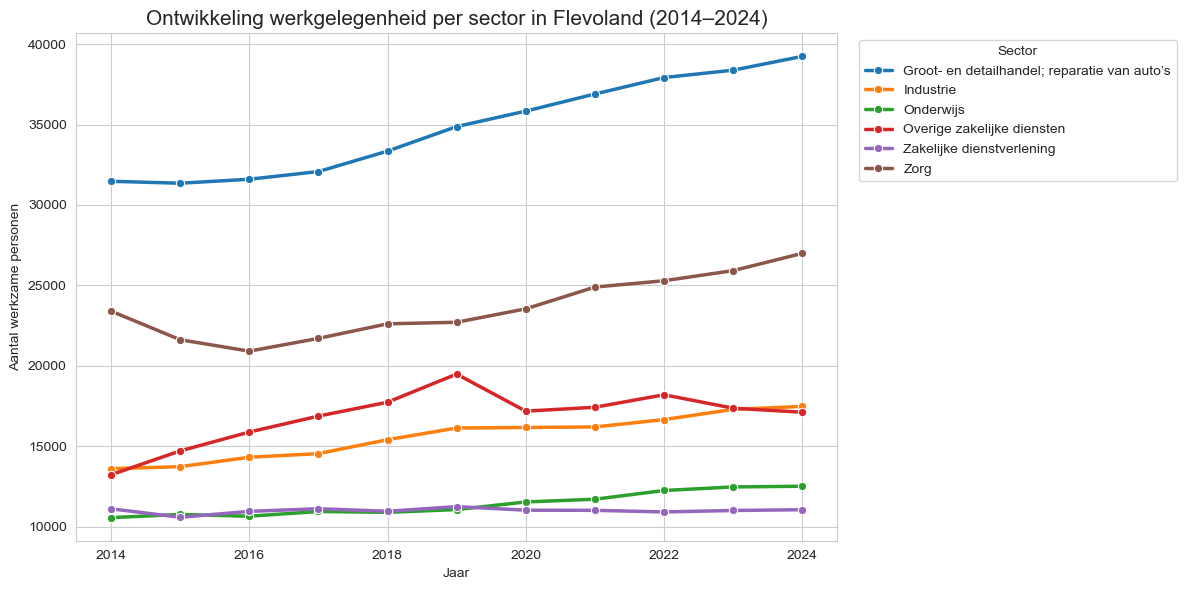

In [12]:
# Top sectoren bepalen
top_sectoren = (
    df_flevo.groupby('sector_code')['wp']
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

# Filter dataset
df_top_sectoren = df_flevo[df_flevo['sector_code'].isin(top_sectoren)]

# Groeperen (NU MET Sector)
df_plot = df_top_sectoren.groupby(['jaar', 'Sector'])['wp'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_plot,
    x='jaar',
    y='wp',
    hue='Sector',
    marker='o',
    linewidth=2.5
)

plt.title('Ontwikkeling werkgelegenheid per sector in Flevoland (2014–2024)', fontsize=15)
plt.xlabel('Jaar')
plt.ylabel('Aantal werkzame personen')

plt.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Om een eerste inzicht te krijgen in de ontwikkeling van werkgelegenheid per sector is een lijngrafiek opgesteld voor de grootste sectoren in Flevoland over de periode 2014–2024.

Uit deze verkennende analyse lijken er duidelijke verschillen te bestaan tussen sectoren. Sommige sectoren vertonen een stijgende trend in werkgelegenheid, terwijl andere sectoren relatief stabiel blijven of meer fluctueren over de tijd.

Met name de sector groot- en detailhandel lijkt een duidelijke groei te laten zien gedurende de onderzochte periode. Ook de zorgsector lijkt een stijgende ontwikkeling te vertonen. Daarentegen lijken sectoren zoals zakelijke dienstverlening en onderwijs minder sterke veranderingen te laten zien en relatief stabiel te blijven.

Daarnaast valt op dat sommige sectoren, zoals overige zakelijke diensten, schommelingen laten zien in de ontwikkeling van werkgelegenheid. Dit kan wijzen op gevoeligheid voor externe factoren.

Deze visualisatie dient als eerste indicatie van sectorale dynamiek en helpt bij het herkennen van patronen in de data. Verdere analyse is nodig om deze observaties te onderbouwen en te bepalen welke sectoren daadwerkelijk groeien, stabiel zijn of krimpen.

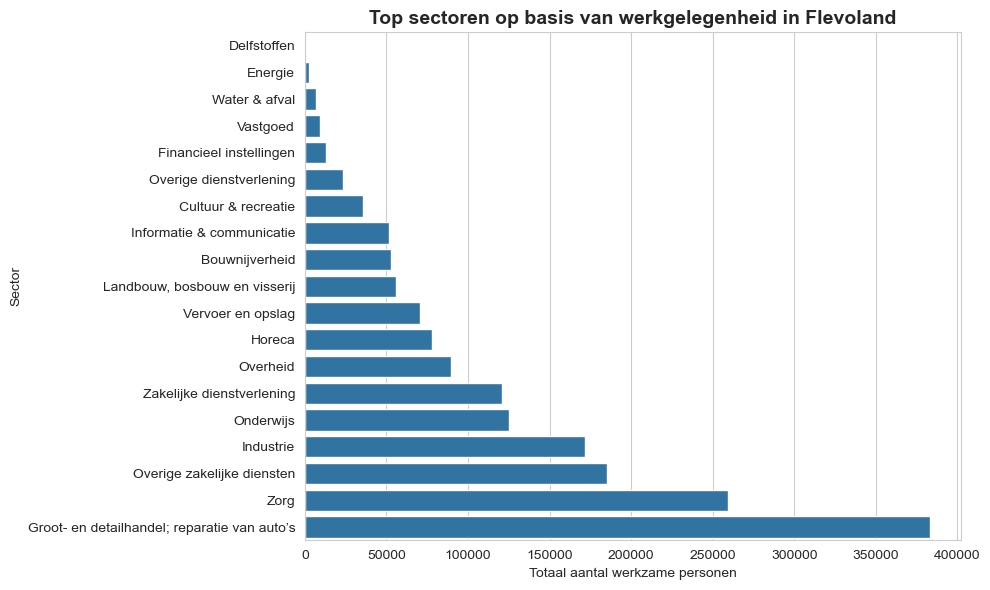

In [13]:
# Data voorbereiden
df_sector_total = df_flevo.groupby('Sector')['wp'].sum().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.barplot(
    x=df_sector_total.values,
    y=df_sector_total.index,
)

plt.title('Top sectoren op basis van werkgelegenheid in Flevoland', fontsize=14, weight='bold')
plt.xlabel('Totaal aantal werkzame personen')
plt.ylabel('Sector')

plt.tight_layout()
plt.show()

Om inzicht te krijgen in de relatieve omvang van sectoren binnen Flevoland is een horizontaal staafdiagram opgesteld waarin de totale werkgelegenheid per sector is weergegeven.

Uit de visualisatie blijkt dat de werkgelegenheid ongelijk verdeeld is over sectoren. Enkele sectoren hebben een duidelijk groter aandeel in de totale werkgelegenheid dan andere sectoren.

Met name de sector groot- en detailhandel lijkt de grootste bijdrage te leveren aan de werkgelegenheid, gevolgd door de zorg en overige zakelijke diensten. Sectoren zoals industrie en onderwijs nemen een middenpositie in.

Aan de andere kant zijn er sectoren met een relatief klein aandeel in werkgelegenheid, zoals delfstoffenwinning en energie.

Deze verkenning geeft een eerste indicatie van welke sectoren dominant zijn binnen de economie van Flevoland en helpt bij het bepalen van de focus voor verdere analyse.

# Data Cleaning


In [14]:
# --- STAP 2: DATA CLEANING ---

# 1. Selecteer alleen relevante kolommen
df_clean = df_flevo[['jaar', 'sector_code', 'sbi_code', 'wp']].copy()

# 2. Verwijder eventuele missende waarden in kernkolommen
df_clean = df_clean.dropna(subset=['jaar', 'sector_code', 'wp'])

# 3. Zorg voor juiste datatypes
df_clean['jaar'] = df_clean['jaar'].astype(int)
df_clean['sector_code'] = df_clean['sector_code'].astype(str).str.strip()
df_clean['sbi_code'] = df_clean['sbi_code'].astype(str).str.strip()
df_clean['wp'] = df_clean['wp'].astype(int)

# 4. Voeg sectornamen toe (mapping heb je al bovenaan staan!)
df_clean['sector_naam'] = df_clean['sector_code'].map(sector_namen)

# 5. Verwijder eventuele onbekende sectoren
df_clean = df_clean.dropna(subset=['sector_naam'])

# 6. Controle
print("Aantal rijen na cleaning:", df_clean.shape[0])
display(df_clean.head())

Aantal rijen na cleaning: 137714


,jaar,sector_code,sbi_code,wp,sector_naam
0,2015,A,1241,4,"Landbouw, bosbouw en visserij"
1,2016,A,1241,2,"Landbouw, bosbouw en visserij"
2,2017,A,1241,2,"Landbouw, bosbouw en visserij"
3,2018,A,1241,2,"Landbouw, bosbouw en visserij"
4,2019,A,1241,2,"Landbouw, bosbouw en visserij"


In de data cleaning fase zijn alleen de relevante variabelen voor de sectoranalyse geselecteerd, namelijk jaar, sector_code, sbi_code en wp. Vervolgens zijn eventuele missende waarden in de kernvariabelen verwijderd en zijn de datatypes gecontroleerd en waar nodig aangepast.

Daarnaast zijn de sectorcodes vertaald naar leesbare sectornamen met behulp van een mapping. Omdat de dataset al een sectorindeling bevatte, was het niet nodig om sectoren opnieuw af te leiden uit de SBI-codes.

Deze aanpak zorgt voor een overzichtelijke en consistente dataset die direct geschikt is voor verdere analyse van sectorale dynamiek.

# Aggregatie

In [15]:
# 1. Groeperen: tel alle werkzame personen op per jaar en per sector
sector_jaar_totaal = df_clean.groupby(['jaar', 'sector_naam'])['wp'].sum().reset_index()

# 2. Pivot table: jaren als rijen, sectoren als kolommen
pivot_df = sector_jaar_totaal.pivot(index='jaar', columns='sector_naam', values='wp').fillna(0)
pivot_df = pivot_df[pivot_df.sum().sort_values(ascending=False).index]
# 3. Resultaat laten zien
display(pivot_df)
pivot_df.shape

sector_naam,Groot- en detailhandel; reparatie van auto’s,Zorg,Overige zakelijke diensten,Industrie,Onderwijs,Zakelijke dienstverlening,Overheid,Horeca,Vervoer en opslag,"Landbouw, bosbouw en visserij",Bouwnijverheid,Informatie & communicatie,Cultuur & recreatie,Overige dienstverlening,Financieel instellingen,Vastgoed,Water & afval,Energie,Delfstoffen
jaar,,,,,,,,,,,,,,,,,,,
2014,31475.0,23405.0,13229.0,13606.0,10561.0,11113.0,8067.0,5951.0,6132.0,5053.0,4260.0,6061.0,3032.0,1739.0,1557.0,748.0,507.0,251.0,4.0
2015,31354.0,21624.0,14710.0,13731.0,10761.0,10585.0,8114.0,6252.0,6118.0,4891.0,4060.0,6007.0,2970.0,1814.0,1520.0,759.0,526.0,250.0,2.0
2016,31601.0,20913.0,15884.0,14316.0,10650.0,10952.0,8022.0,6351.0,5942.0,4851.0,4186.0,6288.0,3055.0,1834.0,1481.0,748.0,532.0,237.0,2.0
2017,32079.0,21706.0,16874.0,14543.0,10945.0,11116.0,7836.0,7012.0,5819.0,4864.0,4448.0,4321.0,3206.0,1930.0,1367.0,768.0,544.0,219.0,2.0
2018,33348.0,22612.0,17739.0,15409.0,10891.0,10959.0,7761.0,7411.0,6358.0,5090.0,4733.0,4328.0,3192.0,2181.0,1033.0,819.0,594.0,223.0,0.0
2019,34876.0,22709.0,19487.0,16136.0,11064.0,11247.0,7732.0,7951.0,6314.0,5307.0,4852.0,4003.0,3419.0,2151.0,1085.0,851.0,682.0,227.0,7.0
2020,35836.0,23544.0,17183.0,16167.0,11538.0,11026.0,8106.0,7500.0,6297.0,5326.0,5028.0,3922.0,3414.0,2151.0,1087.0,891.0,698.0,160.0,3.0
2021,36901.0,24898.0,17425.0,16201.0,11707.0,11017.0,8103.0,7072.0,6543.0,5296.0,5008.0,4000.0,2961.0,2253.0,1030.0,875.0,690.0,161.0,2.0
2022,37923.0,25290.0,18202.0,16658.0,12250.0,10916.0,8266.0,7345.0,6819.0,5113.0,5140.0,4103.0,3147.0,2276.0,959.0,880.0,695.0,280.0,0.0


(11, 19)

Na de data cleaning is de dataset geaggregeerd naar sectorniveau per jaar. Hiervoor is het totaal aantal werkzame personen (wp) berekend per combinatie van jaar en sector_naam.

Vervolgens is een pivot table opgesteld waarin de jaren als rijen en de sectoren als kolommen zijn weergegeven. Hierdoor ontstaat een overzichtelijke tijdreeks per sector.

Deze structuur maakt het mogelijk om de ontwikkeling van werkgelegenheid per sector eenvoudig te analyseren en vormt de basis voor verdere berekeningen, zoals groeipercentages en sectorale vergelijking.

# Cel 4: Berekenen van de Dynamiek

In [16]:
# Aantal jaren (2014 → 2024)
n_jaar = 2024 - 2014

# Dynamiek berekenen
summary_df = pd.DataFrame({
    'WP_2014': pivot_df.loc[2014],
    'WP_2024': pivot_df.loc[2024]
})

# Absolute groei
summary_df['Verschil_Absoluut'] = summary_df['WP_2024'] - summary_df['WP_2014']

# Totale groei (%)
summary_df['Totale_Groei_%'] = (
    (summary_df['Verschil_Absoluut'] / summary_df['WP_2014']) * 100
).round(2)

# CAGR (jaarlijkse groei)
summary_df['CAGR_%'] = (
    ((summary_df['WP_2024'] / summary_df['WP_2014']) ** (1 / n_jaar) - 1) * 100
).round(2)

summary_df = summary_df.replace([np.inf, -np.inf], np.nan)

# kleine sectoren filteren (belangrijk!)
summary_df = summary_df[summary_df['WP_2014'] > 1000]

# NaN verwijderen
summary_df = summary_df.dropna()

# Gemiddelde omvang toevoegen
summary_df['Gemiddelde_omvang'] = (
    summary_df['WP_2014'] + summary_df['WP_2024']
) / 2

def classify(cagr):
    if cagr > 2:
        return 'Groei'
    elif cagr < -1:
        return 'Krimp'
    else:
        return 'Stabiel'

summary_df['Dynamiek'] = summary_df['CAGR_%'].apply(classify)

summary_df = summary_df.sort_values(by='CAGR_%', ascending=False)

display(summary_df)

,WP_2014,WP_2024,Verschil_Absoluut,Totale_Groei_%,CAGR_%,Gemiddelde_omvang,Dynamiek
sector_naam,,,,,,,
Overige dienstverlening,1739.0,2456.0,717.0,41.23,3.51,2097.5,Groei
Bouwnijverheid,4260.0,5706.0,1446.0,33.94,2.97,4983.0,Groei
Horeca,5951.0,7765.0,1814.0,30.48,2.70,6858.0,Groei
Overige zakelijke diensten,13229.0,17116.0,3887.0,29.38,2.61,15172.5,Groei
Industrie,13606.0,17479.0,3873.0,28.47,2.54,15542.5,Groei
Groot- en detailhandel; reparatie van auto’s,31475.0,39239.0,7764.0,24.67,2.23,35357.0,Groei
Cultuur & recreatie,3032.0,3694.0,662.0,21.83,1.99,3363.0,Stabiel
Onderwijs,10561.0,12515.0,1954.0,18.50,1.71,11538.0,Stabiel
Vervoer en opslag,6132.0,7268.0,1136.0,18.53,1.71,6700.0,Stabiel


De analyse van de sectorale dynamiek laat zien dat de ontwikkeling van werkgelegenheid in Flevoland verschilt per sector.

Een aantal sectoren vertoont duidelijke groei, met name overige dienstverlening, bouwnijverheid, horeca, industrie en handel. Deze sectoren hebben zowel een positieve ontwikkeling als een relatief grote omvang en vormen daarmee belangrijke groeisectoren binnen de regio.

Daarnaast zijn er sectoren die relatief stabiel blijven, zoals onderwijs, zorg en overheid. Deze sectoren groeien beperkt, maar laten een consistente ontwikkeling zien en vormen een stabiele basis binnen de economie.

Tegelijkertijd zijn er sectoren die een afname in werkgelegenheid laten zien, zoals informatie en communicatie en de financiële sector. Dit kan wijzen op structurele veranderingen binnen deze sectoren.

De resultaten tonen aan dat de economische ontwikkeling in Flevoland niet uniform is en dat sectorale verschillen een belangrijke rol spelen.

## Visualisatie

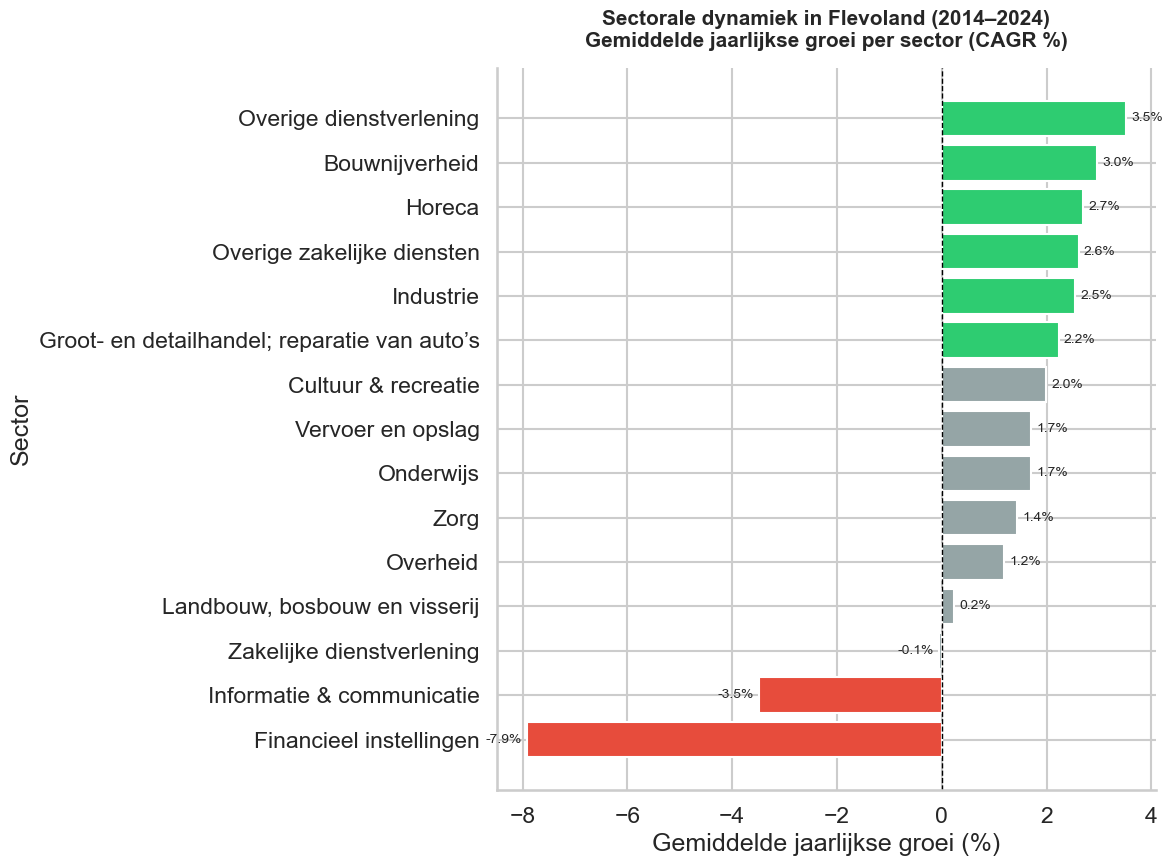

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data voorbereiden
plot_data = summary_df.reset_index().sort_values('CAGR_%', ascending=True)

# Thema
sns.set_theme(style="whitegrid", context="talk")

# Kleuren bepalen
def kleur(cagr):
    if cagr > 2:
        return '#2ecc71'   # groei
    elif cagr < -1:
        return '#e74c3c'   # krimp
    else:
        return '#95a5a6'   # stabiel

colors = plot_data['CAGR_%'].apply(kleur)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    plot_data['sector_naam'],
    plot_data['CAGR_%'],
    color=colors
)

# Nul-lijn
ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Titel en labels
ax.set_title(
    'Sectorale dynamiek in Flevoland (2014–2024)\nGemiddelde jaarlijkse groei per sector (CAGR %)',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Gemiddelde jaarlijkse groei (%)')
ax.set_ylabel('Sector')

# Waarden op balken
for i, v in enumerate(plot_data['CAGR_%']):
    if v >= 0:
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center', ha='left', fontsize=10)
    else:
        ax.text(v - 0.1, i, f'{v:.1f}%', va='center', ha='right', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

### Conclusie Deelvraag 2: Sectorale Dynamiek in Flevoland (2014-2024)
Uit de analyse van de werkgelegenheidsontwikkeling per sector in Flevoland over de periode 2014–2024 blijkt dat de dynamiek per sector duidelijk verschilt.

Een aantal sectoren laat een consistente groei zien. Met name overige dienstverlening, bouwnijverheid, horeca, overige zakelijke diensten, industrie en groot- en detailhandel vertonen een positieve ontwikkeling met een gemiddelde jaarlijkse groei van ongeveer 2% tot 3,5%. Deze sectoren kunnen worden beschouwd als de belangrijkste groeisectoren binnen de regio.

Daarnaast zijn er sectoren die relatief stabiel blijven. Sectoren zoals onderwijs, vervoer en opslag, zorg en overheid laten een beperkte maar constante groei zien. Deze sectoren vormen een stabiele basis binnen de economie van Flevoland en zijn minder gevoelig voor sterke schommelingen.

Tegelijkertijd zijn er ook sectoren die krimp laten zien. Met name de sector informatie en communicatie en de financiële sector vertonen een duidelijke afname in werkgelegenheid. Dit wijst mogelijk op structurele veranderingen, zoals digitalisering en efficiëntieverbeteringen binnen deze sectoren.

Over het geheel genomen kan worden geconcludeerd dat de werkgelegenheid in Flevoland zich niet uniform ontwikkelt, maar dat er duidelijke verschillen bestaan tussen sectoren. Groei concentreert zich vooral in handel, industrie en dienstverlenende sectoren, terwijl sommige kennis- en financiële sectoren juist onder druk staan.

Bij de interpretatie van de resultaten moet rekening worden gehouden met de coronaperiode (2020–2021), die binnen de onderzochte tijdreeks valt. Deze periode heeft in verschillende sectoren geleid tot tijdelijke schommelingen in werkgelegenheid.

Met name sectoren zoals horeca, vervoer en sommige dienstverlenende sectoren kunnen hierdoor een vertekend groeipatroon laten zien, doordat een sterke daling gevolgd werd door herstel in de jaren daarna.

De berekende groeipercentages geven daardoor een gemiddelde ontwikkeling weer over de gehele periode, maar houden geen expliciet onderscheid tussen structurele groei en tijdelijke schokken.

Validatie van de resultaten

De resultaten van de dynamiekanalyse zijn vergeleken met de ontwikkeling van werkgelegenheid per sector over de tijd. Hieruit blijkt dat de richting van groei en krimp grotendeels overeenkomt met de trends in de tijdreeks.

Wel moet worden opgemerkt dat de berekende groeipercentages in sommige gevallen een vertekend beeld kunnen geven, met name bij kleinere sectoren of sectoren die sterk zijn beïnvloed door externe factoren zoals de coronaperiode.

Daarom moeten de resultaten worden geïnterpreteerd in combinatie met de onderliggende tijdreeks, waarbij zowel de trend als de context wordt meegenomen.

In [18]:
pivot_df[['Informatie & communicatie', 'Financieel instellingen']]

sector_naam,Informatie & communicatie,Financieel instellingen
jaar,,
2014,6061.0,1557.0
2015,6007.0,1520.0
2016,6288.0,1481.0
2017,4321.0,1367.0
2018,4328.0,1033.0
2019,4003.0,1085.0
2020,3922.0,1087.0
2021,4000.0,1030.0
2022,4103.0,959.0


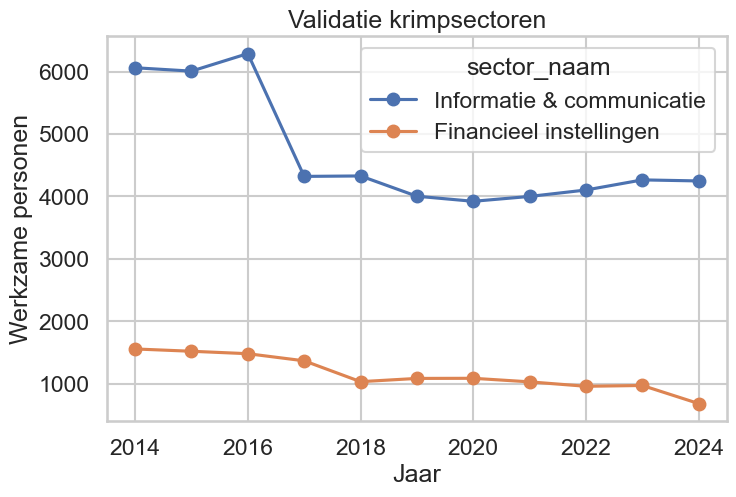

In [20]:
pivot_df[['Informatie & communicatie', 'Financieel instellingen']].plot(marker='o', figsize=(8,5))

plt.title('Validatie krimpsectoren')
plt.xlabel('Jaar')
plt.ylabel('Werkzame personen')
plt.grid(True)
plt.show()

Ter controle van de resultaten is een aanvullende analyse uitgevoerd op sectoren met sterke groei of krimp. Hierbij is gekeken naar de omvang van sectoren en de ontwikkeling over de tijd.

Uit deze validatie blijkt dat extreme groeipercentages vaak voorkomen bij sectoren met een kleine omvang. Daarnaast is vastgesteld dat sommige schommelingen, zoals bij informatie en communicatie, mogelijk het gevolg zijn van veranderingen in de dataset in plaats van daadwerkelijke economische ontwikkelingen.

In [19]:
# Bestanden opslaan voor de teamleider (Faysal)

# 1. De volledige trend-tabel (WP per sector per jaar)
pivot_df.to_excel('../../Data/processed/deelvraag2_sectorale_trends.xlsx')

# 2. De samenvatting met groeipercentages en CAGR
summary_df.to_excel('../../Data/processed/deelvraag2_groei_samenvatting.xlsx')

print("Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.")

Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.
